In [33]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [35]:
#dataset
DATA_PATH = Path("../data/raw/Dummy Data HSS.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(4572, 5)


,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [36]:
#colonnes
print(df.columns.tolist())

#infos
df.info()

display(df.head())

['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']
<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   str    
 4   Sales         4566 non-null   float64
dtypes: float64(4), str(1)
memory usage: 178.7 KB


,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [37]:
#rename columns
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())
df.head()

['tv', 'radio', 'social_media', 'influencer', 'sales']


,tv,radio,social_media,influencer,sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [38]:
#na values
missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    "missing_values": missing_values,
    "missing_percent": missing_percent
})

display(missing_df)

,missing_values,missing_percent
tv,10,0.22
radio,4,0.09
social_media,6,0.13
influencer,0,0.00
sales,6,0.13


### Interprétation — valeurs manquantes

Le dataset contient très peu de valeurs manquantes : `tv` contient 10 valeurs nulles, `radio` 4, `social_media` 6 et `sales` 6. Les pourcentages sont tous inférieurs à 0,25 %, ce qui signifie que le problème reste très limité par rapport au volume total de données. Comme `sales` est la variable cible, il est préférable de supprimer les lignes où cette valeur est absente. Pour les budgets marketing, la suppression des lignes incomplètes reste aussi acceptable ici car la perte de données est très faible. Cette décision permet de garder un dataset simple, cohérent et sans imputation artificielle.


In [39]:
#clean df
essential_cols = ["tv", "radio", "social_media", "influencer", "sales"]
df = df.dropna(subset=essential_cols).copy()

In [40]:
#doublons

duplicates = df.duplicated().sum()

print("doublons :", duplicates)

if duplicates > 0:
    display(df[df.duplicated()])
    df = df.drop_duplicates()

doublons : 0


### Interprétation — doublons

Aucun doublon strict n’a été détecté dans le dataset. Il n’est donc pas nécessaire de supprimer des lignes pour cette raison. C’est un bon point pour la qualité des données, car cela évite qu’une même campagne soit comptée plusieurs fois et influence artificiellement les statistiques ou l’entraînement des modèles.


In [41]:
#stats
display(df.describe())

display(df.describe(include="object"))

,tv,radio,social_media,sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54.062912,18.157533,3.323473,192.413332
std,26.104942,9.663260,2.211254,93.019873
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.555355,1.530822,112.434612
50%,53.000000,17.859513,3.055565,188.963678
75%,77.000000,25.640603,4.804919,272.324236
max,100.000000,48.871161,13.981662,364.079751


C:\Users\dimit\AppData\Local\Temp\ipykernel_22268\2735351308.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,influencer
count,4546
unique,4
top,Mega
freq,1152


In [42]:
#dtypes

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Variables numériques :", numeric_cols)
print("Variables catégorielles :", categorical_cols)

Variables numériques : ['tv', 'radio', 'social_media', 'sales']
Variables catégorielles : ['influencer']


C:\Users\dimit\AppData\Local\Temp\ipykernel_22268\2862913840.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


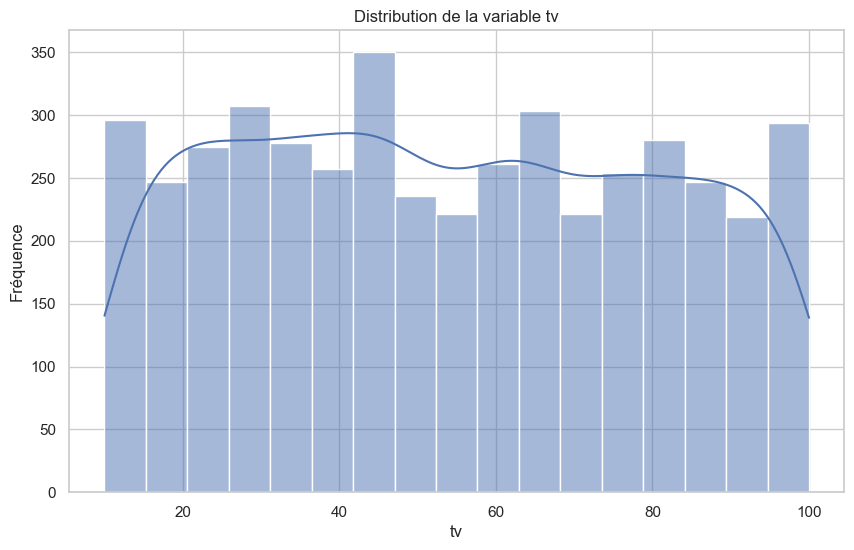

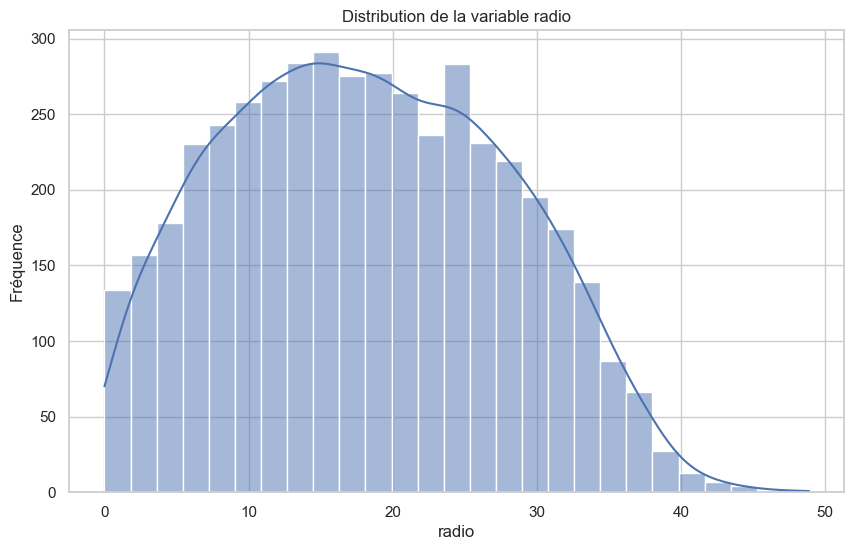

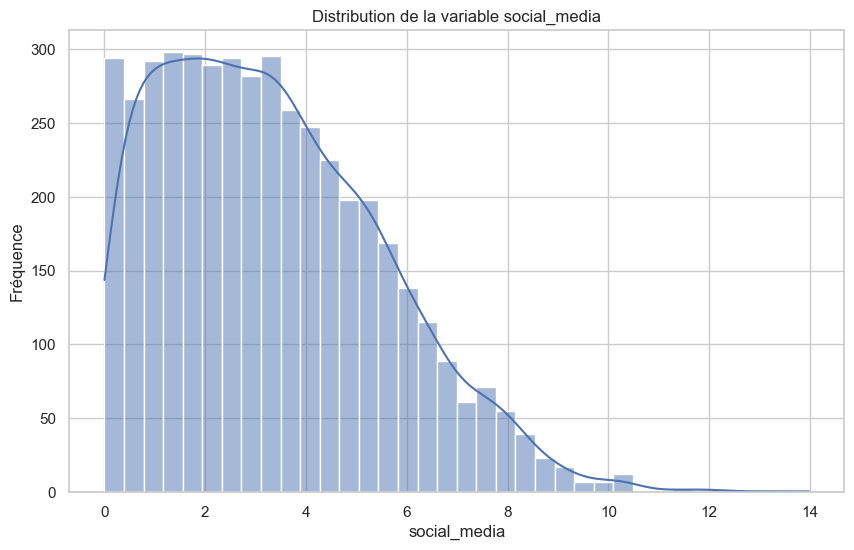

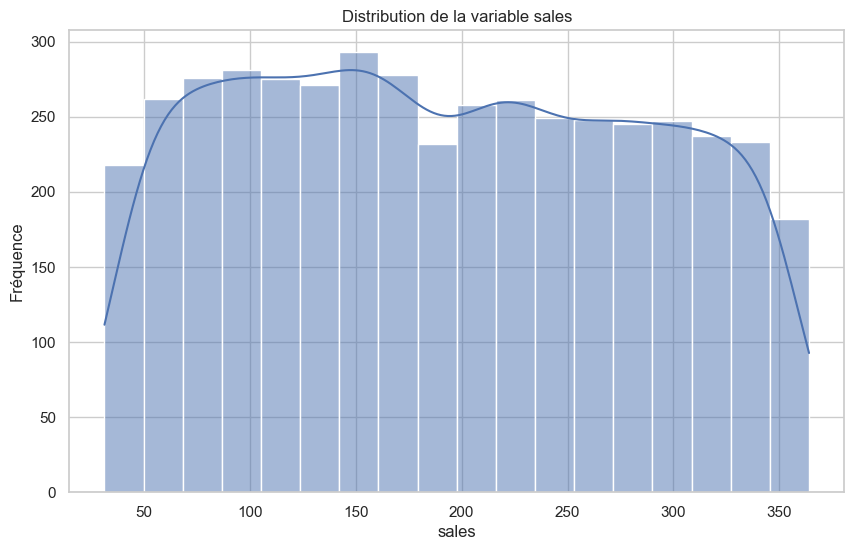

In [43]:
#distribution

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution de la variable {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

### Interprétation — distributions des variables numériques

Les distributions montrent que les budgets `tv`, `radio` et `social_media` ne sont pas répartis de la même manière. Le budget TV couvre une plage assez large, ce qui permettra au modèle d’apprendre différents niveaux d’investissement. Le budget Radio est plus concentré, tandis que `social_media` possède une distribution plus asymétrique avec quelques valeurs plus élevées. La variable `sales` présente une dispersion importante, ce qui confirme l’intérêt d’un modèle de régression pour prédire les ventes à partir des budgets marketing.


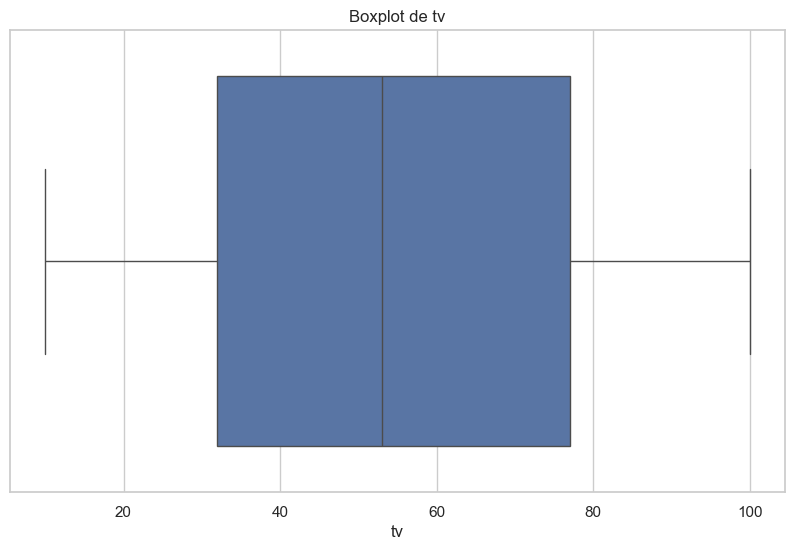

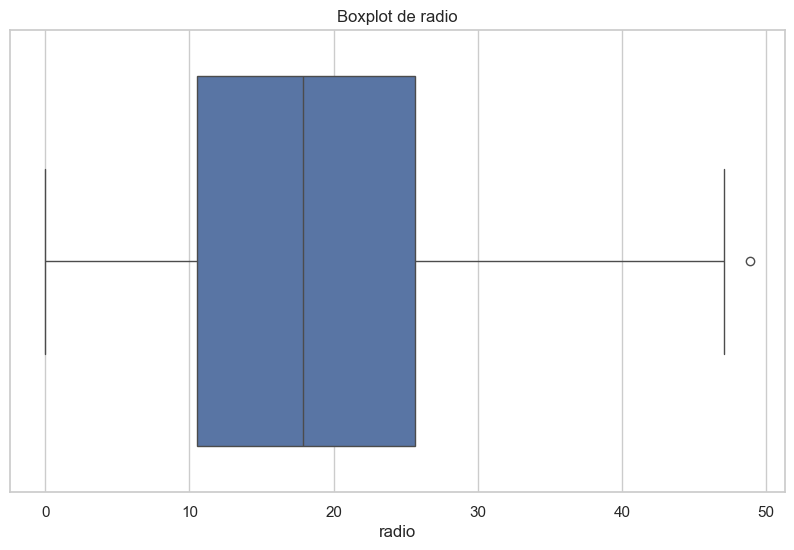

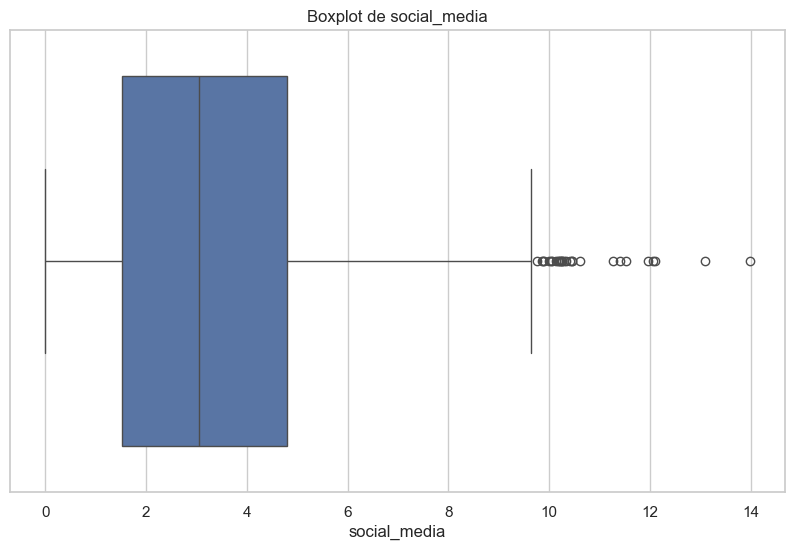

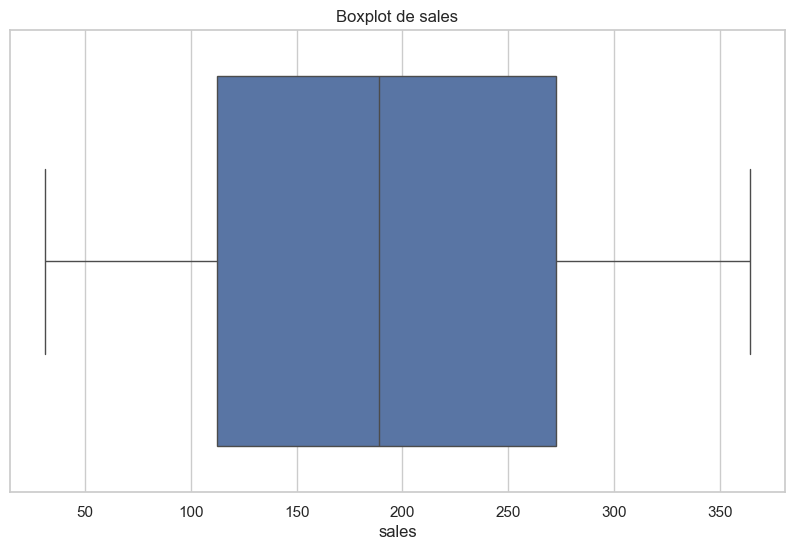

In [44]:
#extreme values

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

### Interprétation — valeurs extrêmes

Les boxplots permettent de repérer visuellement les valeurs atypiques. Les variables `tv` et `sales` ne présentent pas d’anomalies importantes. En revanche, `social_media` contient plusieurs valeurs élevées par rapport au reste de la distribution. Ces valeurs ne doivent pas être supprimées automatiquement, car elles peuvent correspondre à de vraies campagnes où le budget Social Media est plus important. Pour `radio`, un seul point semble atypique, mais il reste cohérent avec une campagne marketing plus élevée que la moyenne.


influencer
Mega     1152
Micro    1148
Nano     1134
Macro    1112
Name: count, dtype: int64


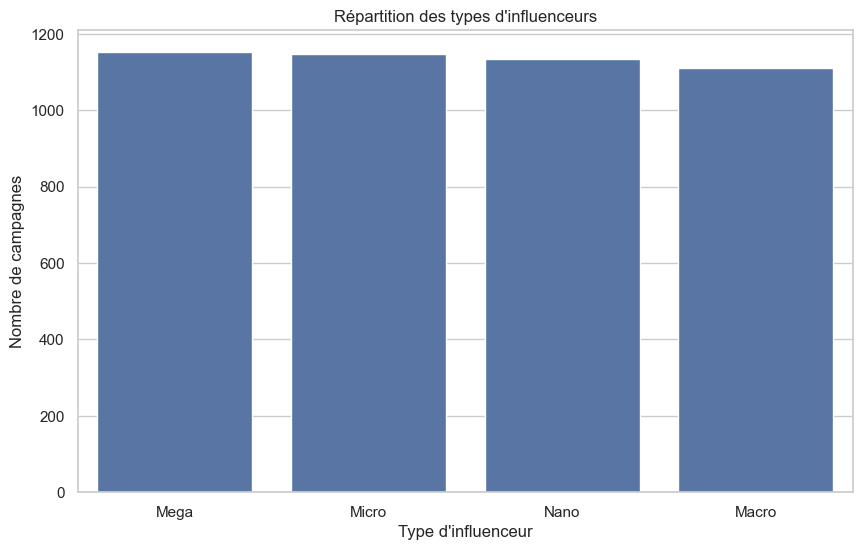

In [45]:
#influencer types

if "influencer" in df.columns:
    print(df["influencer"].value_counts())

    plt.figure()
    sns.countplot(data=df, x="influencer", order=df["influencer"].value_counts().index)
    plt.title("Répartition des types d'influenceurs")
    plt.xlabel("Type d'influenceur")
    plt.ylabel("Nombre de campagnes")
    plt.show()

### Interprétation — répartition des influenceurs

Les quatre catégories d’influenceurs sont bien représentées dans le dataset. Les effectifs sont très proches : `Mega`, `Micro`, `Nano` et `Macro` apparaissent dans des proportions équilibrées. Cela est positif pour l’analyse, car le modèle ne sera pas fortement biaisé vers une seule catégorie d’influenceur.


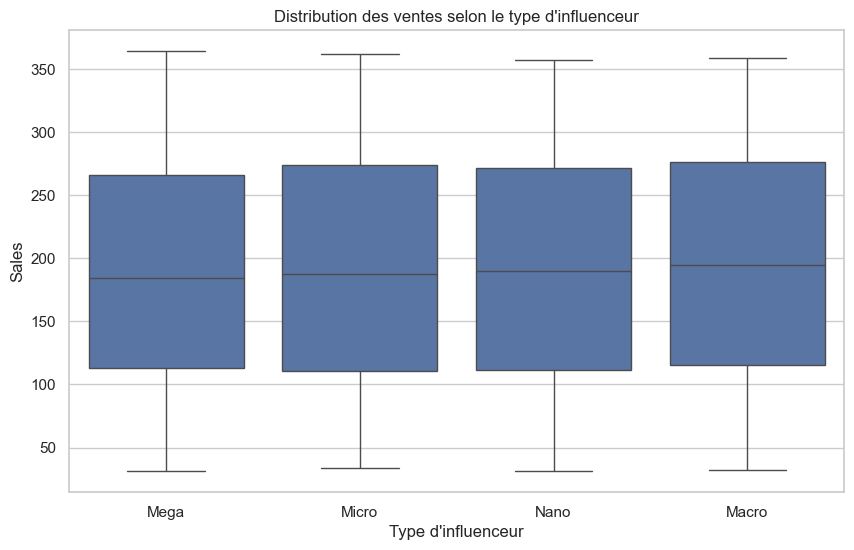

,mean,median,min,max,count
influencer,,,,,
Macro,196.066150,194.459266,32.566825,358.420739,1112
Nano,191.708827,189.655438,31.199409,357.124573,1134
Micro,191.578370,187.839762,33.719607,362.042123,1148
Mega,190.412908,184.068201,31.402262,364.079751,1152


In [46]:
#influencers and sales

if "influencer" in df.columns and "sales" in df.columns:
    plt.figure()
    sns.boxplot(data=df, x="influencer", y="sales")
    plt.title("Distribution des ventes selon le type d'influenceur")
    plt.xlabel("Type d'influenceur")
    plt.ylabel("Sales")
    plt.show()

    influencer_sales = df.groupby("influencer")["sales"].agg(["mean", "median", "min", "max", "count"])
    display(influencer_sales.sort_values(by="mean", ascending=False))

### Interprétation — ventes selon le type d’influenceur

Les ventes moyennes sont assez proches entre les différents types d’influenceurs. La catégorie `Macro` semble légèrement au-dessus en moyenne, mais l’écart reste faible. Cela signifie que le type d’influenceur peut apporter une information complémentaire, mais il ne semble pas être le facteur principal expliquant les ventes. Les budgets marketing, notamment TV et Radio, paraissent probablement plus déterminants.


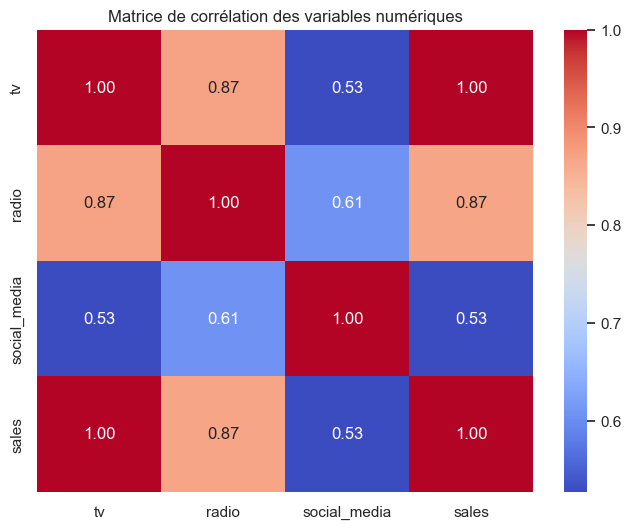

In [47]:
#corr matrix

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation des variables numériques")
plt.show()

### Interprétation — matrice de corrélation

La matrice de corrélation montre une relation très forte entre `tv` et `sales`. La variable `radio` est aussi fortement liée aux ventes, tandis que `social_media` présente une corrélation positive mais plus modérée. Cette première analyse indique que les investissements TV semblent être le canal le plus explicatif des ventes dans ce dataset. Il faudra cependant confirmer cela avec les modèles et l’analyse d’importance des variables.


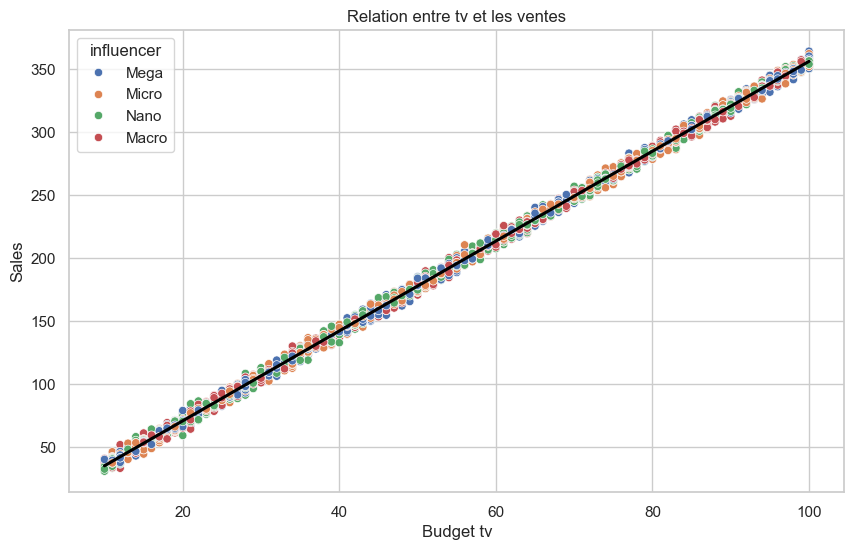

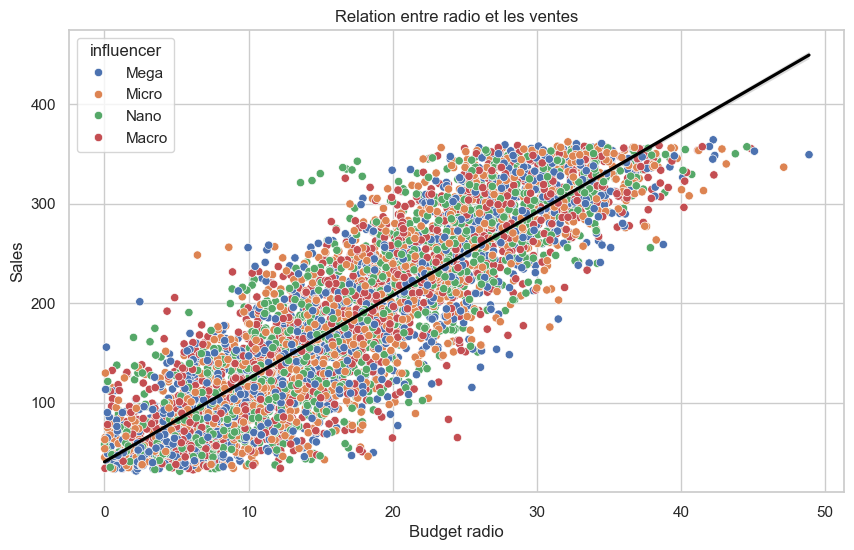

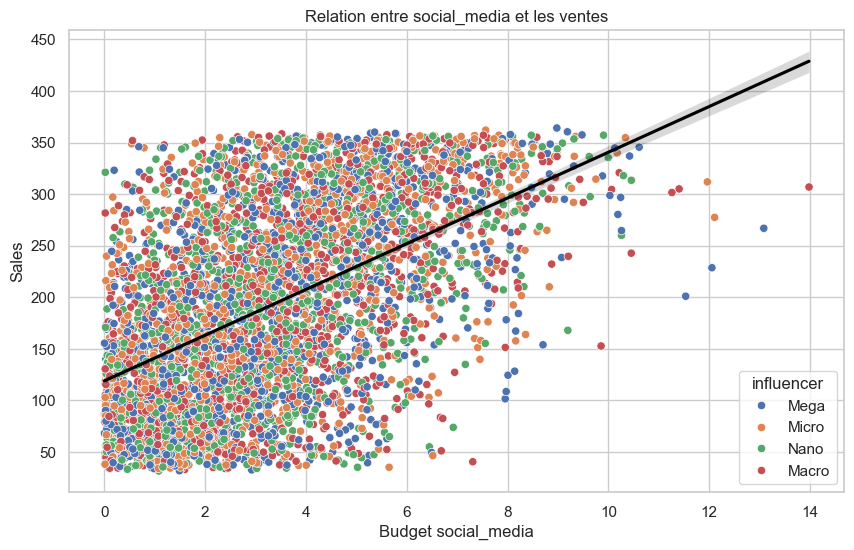

In [48]:
#marketing-ventes

budget_cols = [col for col in ["tv", "radio", "social_media"] if col in df.columns]

for col in budget_cols:
    plt.figure()
    sns.scatterplot(data=df, x=col, y="sales", hue="influencer" if "influencer" in df.columns else None)
    sns.regplot(data=df, x=col, y="sales", scatter=False, color="black")
    plt.title(f"Relation entre {col} et les ventes")
    plt.xlabel(f"Budget {col}")
    plt.ylabel("Sales")
    plt.show()

### Interprétation — relation entre budgets marketing et ventes

Les nuages de points confirment que les ventes augmentent globalement lorsque les budgets augmentent. La relation entre `tv` et `sales` est particulièrement linéaire et très marquée. La relation avec `radio` est aussi positive, mais un peu moins forte. Pour `social_media`, la tendance est positive mais plus dispersée, ce qui suggère que son effet est plus variable ou dépend davantage des autres canaux. Cette observation justifie l’utilisation de plusieurs modèles, car certains modèles pourront mieux capturer les effets combinés entre canaux.


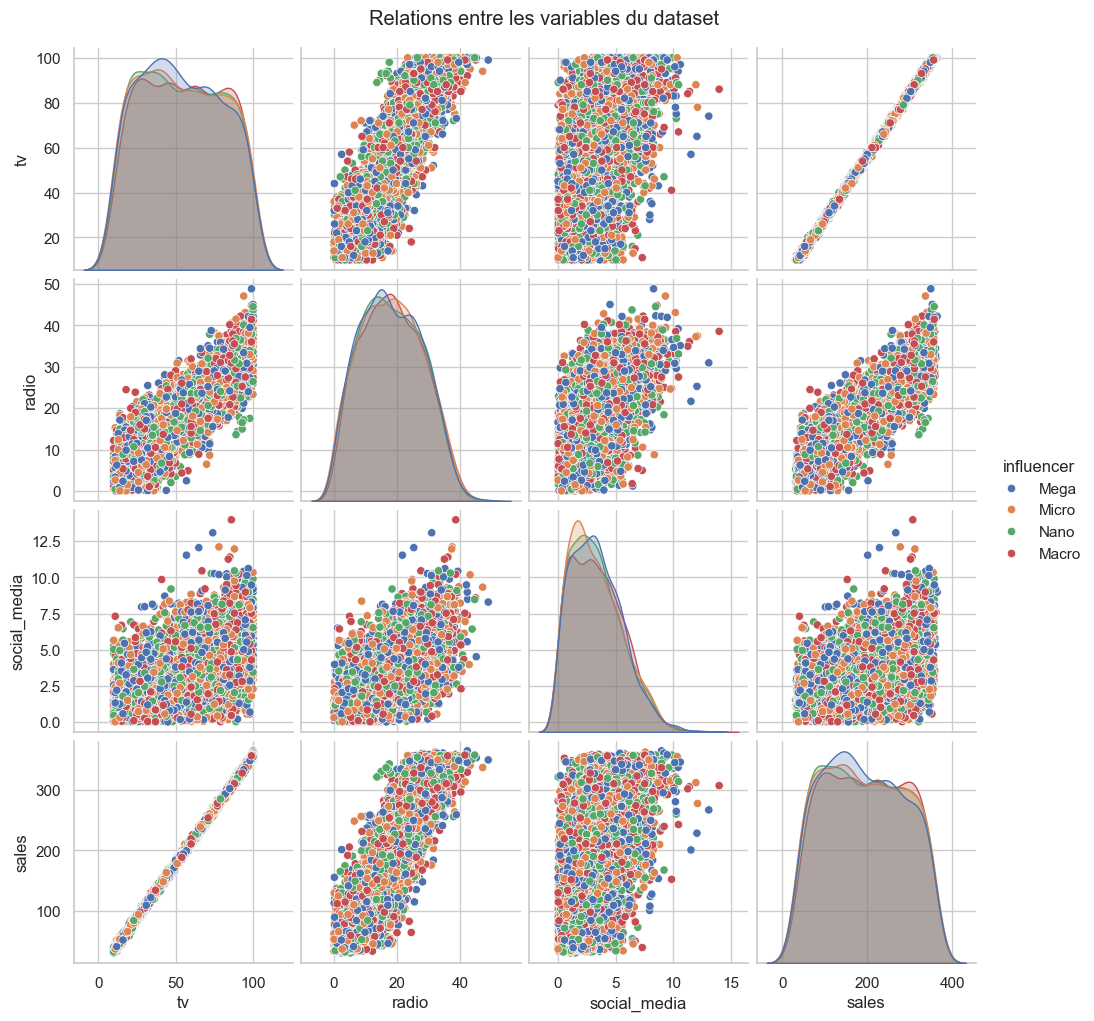

In [49]:


if "influencer" in df.columns:
    sns.pairplot(df, hue="influencer")
else:
    sns.pairplot(df)

plt.suptitle("Relations entre les variables du dataset", y=1.02)
plt.show()

### Interprétation — pairplot global

Le pairplot permet de visualiser les relations entre toutes les variables numériques. On observe surtout une forte relation entre les budgets marketing et les ventes, en particulier avec la TV. Les catégories d’influenceurs ne créent pas de séparation très nette dans les graphiques, ce qui confirme que le type d’influenceur n’explique pas seul les différences de ventes. Cette visualisation sert surtout à confirmer les tendances observées dans les graphiques précédents.


In [50]:
#budget total et ROI

df["total_budget"] = df[budget_cols].sum(axis=1)

# ROI = ventes / budget total
# On évite la division par zéro
df["roi"] = np.where(df["total_budget"] > 0, df["sales"] / df["total_budget"], np.nan)

df[["tv", "radio", "social_media", "total_budget", "sales", "roi"]].head()

,tv,radio,social_media,total_budget,sales,roi
0,16.0,6.566231,2.907983,25.474214,54.732757,2.148555
1,13.0,9.237765,2.409567,24.647332,46.677897,1.893832
2,41.0,15.886446,2.913410,59.799856,150.177829,2.511341
3,83.0,30.020028,6.922304,119.942332,298.246340,2.486581
4,15.0,8.437408,1.405998,24.843406,56.594181,2.278036


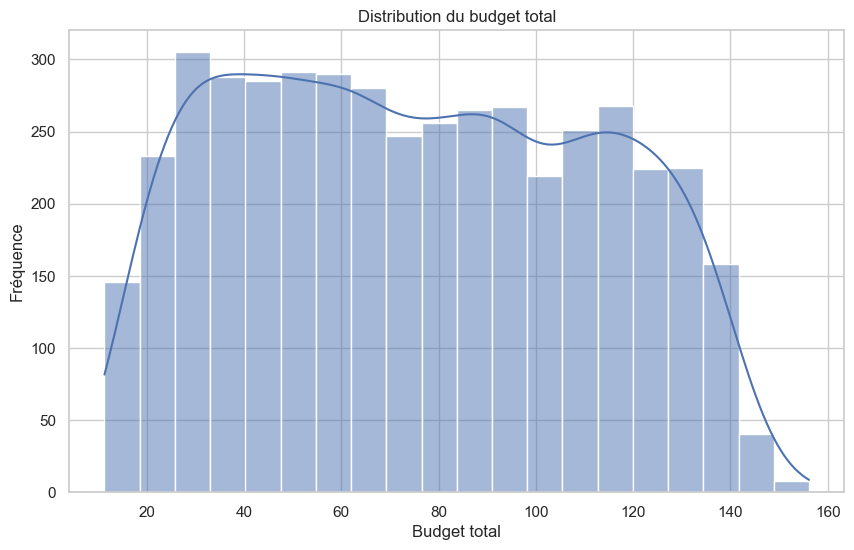

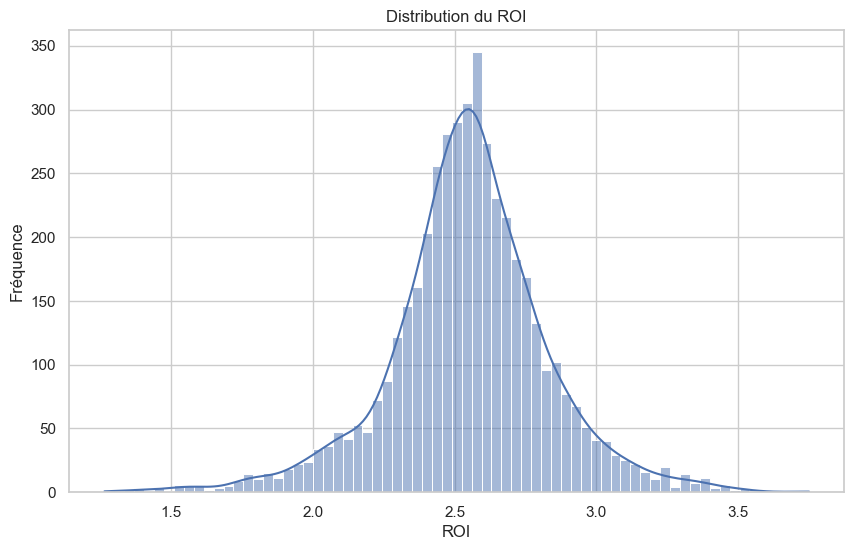

In [51]:
#analyse

plt.figure()
sns.histplot(df["total_budget"], kde=True)
plt.title("Distribution du budget total")
plt.xlabel("Budget total")
plt.ylabel("Fréquence")
plt.show()

plt.figure()
sns.histplot(df["roi"], kde=True)
plt.title("Distribution du ROI")
plt.xlabel("ROI")
plt.ylabel("Fréquence")
plt.show()

### Interprétation — budget total et ROI

Le budget total permet de résumer l’investissement global d’une campagne. Sa distribution est assez étendue, ce qui montre que les campagnes n’ont pas toutes le même niveau d’investissement. Le ROI est globalement concentré autour d’une zone centrale, mais avec quelques valeurs plus hautes ou plus basses. Ces variations sont intéressantes d’un point de vue métier, car elles permettent d’identifier les campagnes qui génèrent beaucoup de ventes par rapport au budget investi.


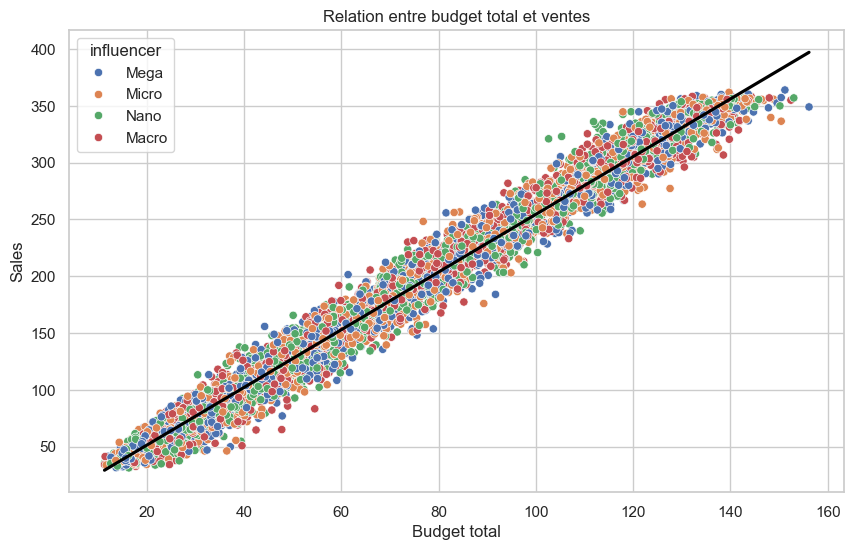

In [52]:
# Relation budget total / ventes

plt.figure()
sns.scatterplot(data=df, x="total_budget", y="sales", hue="influencer" if "influencer" in df.columns else None)
sns.regplot(data=df, x="total_budget", y="sales", scatter=False, color="black")
plt.title("Relation entre budget total et ventes")
plt.xlabel("Budget total")
plt.ylabel("Sales")
plt.show()

### Interprétation — budget total et ventes

Le graphique montre une relation positive nette entre le budget total et les ventes : plus une campagne investit, plus les ventes attendues sont élevées. Cette relation confirme que le budget global est un bon indicateur de performance commerciale. Cependant, le budget total est calculé à partir de `tv`, `radio` et `social_media`, donc il faudra être prudent si on l’utilise comme variable dans le modèle, car il est très corrélé avec les variables de départ.


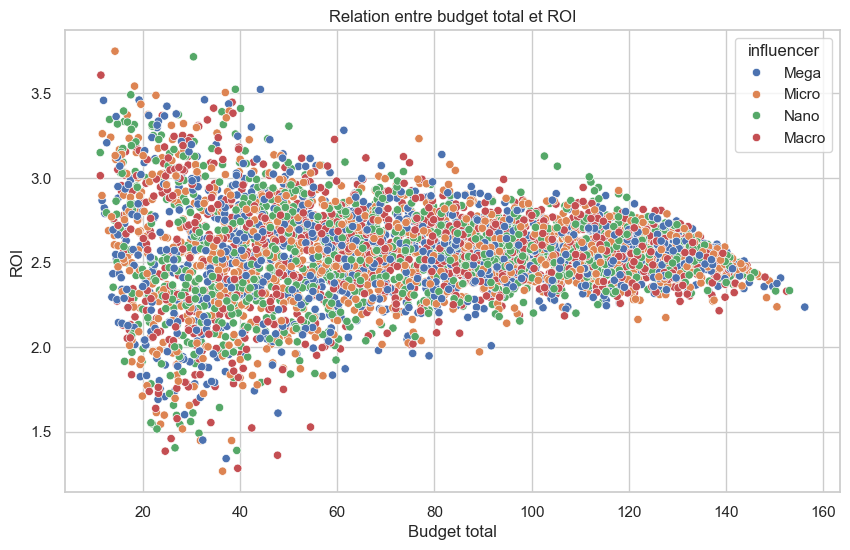

In [53]:
# Relation budget total / ROI

plt.figure()
sns.scatterplot(data=df, x="total_budget", y="roi", hue="influencer" if "influencer" in df.columns else None)
plt.title("Relation entre budget total et ROI")
plt.xlabel("Budget total")
plt.ylabel("ROI")
plt.show()

### Interprétation — budget total et ROI

Le ROI ne progresse pas forcément avec le budget total. On observe que certaines campagnes avec un budget plus faible peuvent obtenir un ROI élevé, tandis que des campagnes plus coûteuses peuvent avoir un ROI plus stable ou plus faible. Cela suggère un possible phénomène de rendement décroissant : investir plus augmente les ventes, mais n’augmente pas toujours proportionnellement la rentabilité.


,mean,median,min,max,count
influencer,,,,,
Nano,2.549850,2.540776,1.388173,3.716003,1134
Macro,2.549624,2.559097,1.282401,3.607731,1112
Micro,2.547419,2.553280,1.265415,3.749347,1148
Mega,2.543154,2.552650,1.339874,3.522938,1152


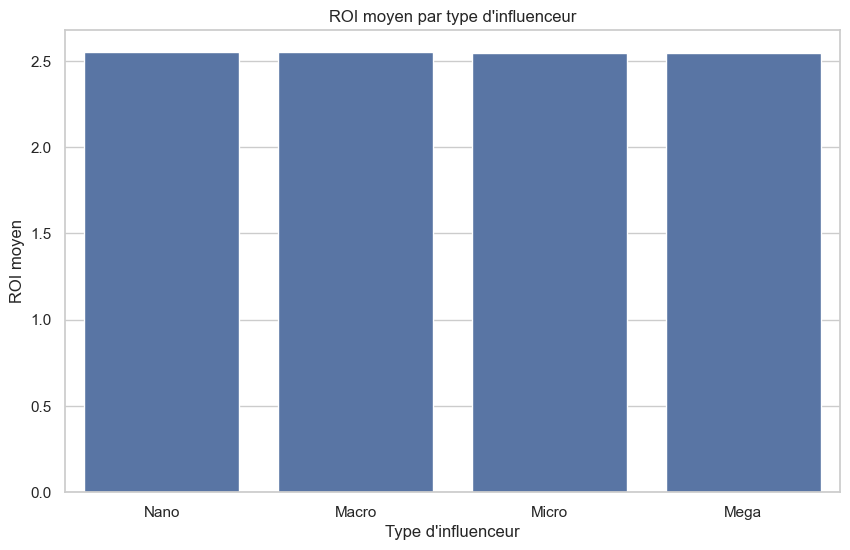

In [54]:
#roi par influencer

if "influencer" in df.columns:
    roi_by_influencer = df.groupby("influencer")["roi"].agg(["mean", "median", "min", "max", "count"])
    display(roi_by_influencer.sort_values(by="mean", ascending=False))

    plt.figure()
    sns.barplot(
        data=df,
        x="influencer",
        y="roi",
        estimator="mean",
        errorbar=None,
        order=df.groupby("influencer")["roi"].mean().sort_values(ascending=False).index
    )
    plt.title("ROI moyen par type d'influenceur")
    plt.xlabel("Type d'influenceur")
    plt.ylabel("ROI moyen")
    plt.show()

### Interprétation — ROI moyen par type d’influenceur

Le ROI moyen est très proche entre les différentes catégories d’influenceurs. Les écarts sont faibles, ce qui indique que le choix du type d’influenceur n’a pas un impact massif sur la rentabilité globale dans ce dataset. Cette variable reste tout de même utile pour le modèle, car elle peut interagir avec les budgets marketing, mais elle ne semble pas être le facteur dominant du ROI.


In [55]:
# ==============================
# 19. PART DE CHAQUE CANAL DANS LE BUDGET TOTAL
# ==============================

for col in budget_cols:
    df[f"{col}_share"] = df[col] / df["total_budget"]

share_cols = [f"{col}_share" for col in budget_cols]

display(df[share_cols].head())

,tv_share,radio_share,social_media_share
0,0.628086,0.257760,0.114154
1,0.527440,0.374798,0.097762
2,0.685620,0.265660,0.048719
3,0.691999,0.250287,0.057714
4,0.603782,0.339624,0.056594


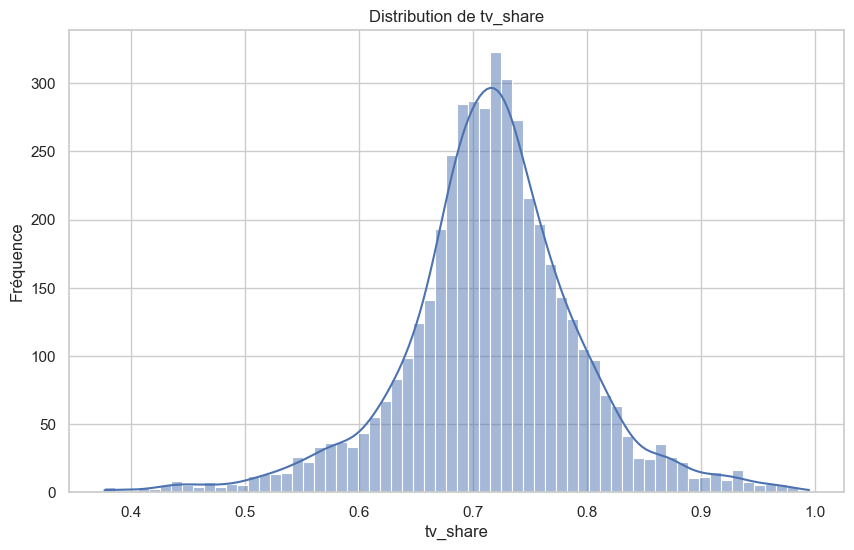

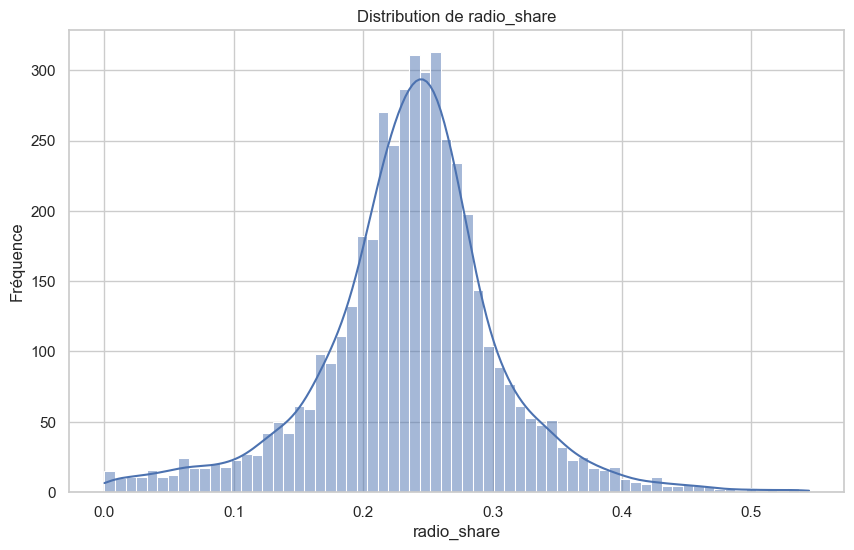

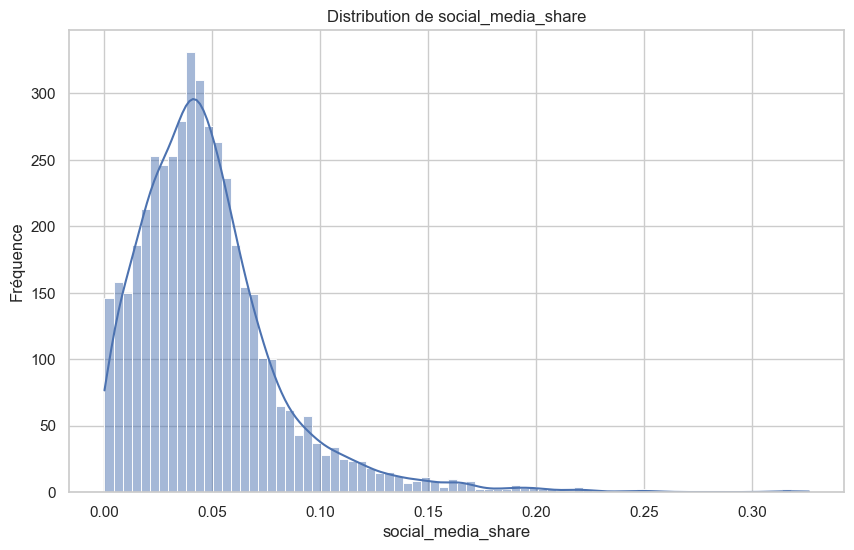

In [56]:
# Distribution des parts budgétaires

for col in share_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

### Interprétation — part de chaque canal dans le budget

Les parts budgétaires permettent de comprendre comment le budget total est réparti entre TV, Radio et Social Media. On observe que la TV représente souvent la part principale du budget, ce qui est cohérent avec sa forte relation avec les ventes. La part Social Media est généralement plus faible, mais certaines campagnes lui accordent un poids plus important. Ces variables peuvent être utiles pour une analyse métier, mais il faut éviter d’ajouter trop de variables redondantes dans le modèle.


In [57]:
#outliers

def detect_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = dataframe[
        (dataframe[column] < lower_bound) |
        (dataframe[column] > upper_bound)
    ]
    
    return outliers, lower_bound, upper_bound


for col in numeric_cols + ["total_budget", "roi"]:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"\nVariable : {col}")
    print(f"Bornes : [{lower:.2f}, {upper:.2f}]")
    print(f"Nombre d'outliers : {len(outliers)}")


Variable : tv
Bornes : [-35.50, 144.50]
Nombre d'outliers : 0

Variable : radio
Bornes : [-12.07, 48.27]
Nombre d'outliers : 1

Variable : social_media
Bornes : [-3.38, 9.72]
Nombre d'outliers : 28

Variable : sales
Bornes : [-127.40, 512.16]
Nombre d'outliers : 0

Variable : total_budget
Bornes : [-49.10, 200.25]
Nombre d'outliers : 0

Variable : roi
Bornes : [1.97, 3.14]
Nombre d'outliers : 258


### Interprétation — détection des outliers

La méthode IQR détecte peu ou pas d’outliers sur `tv`, `sales` et `total_budget`. En revanche, `social_media` possède plusieurs valeurs atypiques et `roi` présente beaucoup d’outliers. Pour `social_media`, ces valeurs peuvent correspondre à des campagnes réellement plus orientées vers ce canal. Pour `roi`, les outliers doivent être interprétés avec prudence : un ROI élevé peut venir d’un petit budget total combiné à des ventes correctes. Il ne faut donc pas supprimer ces lignes automatiquement.


In [66]:
#visualiser outliers

social_outliers, social_lower, social_upper = detect_outliers_iqr(df, "social_media")

print("Borne haute social_media :", social_upper)
display(
    social_outliers
    .sort_values(by="social_media", ascending=False)
    [["tv", "radio", "social_media", "influencer", "sales", "total_budget", "roi"]]
    .head(20)
)

Borne haute social_media : 9.71606546175


,tv,radio,social_media,influencer,sales,total_budget,roi
2346,86.0,38.575779,13.981662,Macro,306.807598,138.557441,2.214299
867,74.0,30.967507,13.083957,Mega,266.757198,118.051464,2.259669
2091,78.0,37.477608,12.108017,Micro,277.337551,127.585625,2.173737
3500,65.0,25.285103,12.054749,Mega,228.454384,102.339852,2.232311
2295,88.0,37.287223,11.964333,Micro,311.773774,137.251556,2.271550
2096,57.0,21.666267,11.534626,Mega,200.805601,90.200893,2.226204
504,85.0,36.077756,11.403625,Macro,304.970625,132.481381,2.301989
1412,84.0,34.984570,11.260430,Macro,301.493120,130.244999,2.314815
2418,97.0,35.151475,10.610895,Mega,345.506826,142.762370,2.420153
4279,88.0,33.122470,10.455109,Nano,313.341447,131.577579,2.381420


### Interprétation — inspection des outliers Social Media

Les campagnes identifiées comme outliers sur `social_media` ont surtout des budgets Social Media très élevés par rapport à la majorité des campagnes. Cependant, les valeurs restent cohérentes avec des campagnes plus importantes et ne semblent pas être des erreurs de saisie. Il est donc préférable de les conserver, car elles peuvent aider le modèle à apprendre le comportement des campagnes avec un investissement Social Media élevé.


In [58]:
#top des roi

top_roi = df.sort_values(by="roi", ascending=False).head(10)

display(top_roi)

,tv,radio,social_media,influencer,sales,total_budget,roi,tv_share,radio_share,social_media_share
4560,14.0,0.021883,0.301150,Micro,53.702021,14.323033,3.749347,0.977447,0.001528,0.021026
1979,30.0,0.179656,0.280326,Nano,113.189378,30.459982,3.716003,0.984899,0.005898,0.009203
4044,10.0,1.294194,0.128503,Macro,41.210016,11.422697,3.607731,0.875450,0.113300,0.011250
1798,17.0,0.043082,1.299324,Micro,64.981057,18.342406,3.542668,0.926814,0.002349,0.070837
367,38.0,0.857281,0.218739,Nano,137.697369,39.076020,3.523833,0.972463,0.021939,0.005598
3479,44.0,0.132418,0.091141,Mega,155.796840,44.223559,3.522938,0.994945,0.002994,0.002061
2408,36.0,0.066123,0.947360,Micro,129.724321,37.013482,3.504786,0.972619,0.001786,0.025595
2144,17.0,0.103555,0.469528,Nano,61.355648,17.573083,3.491456,0.967389,0.005893,0.026719
2138,22.0,0.561492,0.182885,Micro,79.337079,22.744376,3.488206,0.967272,0.024687,0.008041
3830,32.0,0.084175,0.643276,Mega,113.300857,32.727451,3.461952,0.977772,0.002572,0.019656


### Interprétation — campagnes avec le meilleur ROI

Les campagnes ayant le meilleur ROI ne sont pas forcément celles qui ont les ventes les plus élevées. Elles ont souvent un budget total relativement faible, mais génèrent un niveau de ventes intéressant par rapport à ce budget. Cela montre que le ROI mesure davantage l’efficacité de l’investissement que le volume brut de ventes.


In [59]:
#top 10 ventes
top_sales = df.sort_values(by="sales", ascending=False).head(10)

display(top_sales)

,tv,radio,social_media,influencer,sales,total_budget,roi,tv_share,radio_share,social_media_share
1925,100.0,42.225232,8.977117,Mega,364.079751,151.202349,2.407897,0.661365,0.279263,0.059372
2823,100.0,32.148208,7.565100,Micro,362.042123,139.713307,2.591322,0.715751,0.230101,0.054147
2412,100.0,34.488205,9.187200,Mega,360.400053,143.675404,2.508432,0.696013,0.240043,0.063944
3338,100.0,32.735142,5.361312,Mega,360.109683,138.096454,2.607668,0.724132,0.237045,0.038823
2314,100.0,27.779895,5.280721,Mega,359.038843,133.060616,2.698310,0.751537,0.208776,0.039687
1408,100.0,34.369133,5.773973,Mega,358.897563,140.143105,2.560936,0.713556,0.245243,0.041201
2378,100.0,28.656719,3.518440,Macro,358.420739,132.175158,2.711710,0.756572,0.216809,0.026620
453,100.0,38.470629,5.793620,Macro,358.350539,144.264249,2.483987,0.693172,0.266668,0.040160
3633,100.0,30.107064,8.054540,Mega,357.788195,138.161604,2.589636,0.723790,0.217912,0.058298
2442,100.0,31.420838,2.924103,Micro,357.587130,134.344941,2.661709,0.744353,0.233882,0.021766


### Interprétation — campagnes avec les plus fortes ventes

Les campagnes avec les ventes les plus élevées ont généralement un budget TV très important, souvent au maximum observé dans le dataset. Cela renforce l’idée que la TV est fortement liée au volume de ventes. En revanche, ces campagnes ne sont pas automatiquement les meilleures en ROI, car elles nécessitent aussi un budget total important.


sales_category
Low Performance       1516
Medium Performance    1515
High Performance      1515
Name: count, dtype: int64


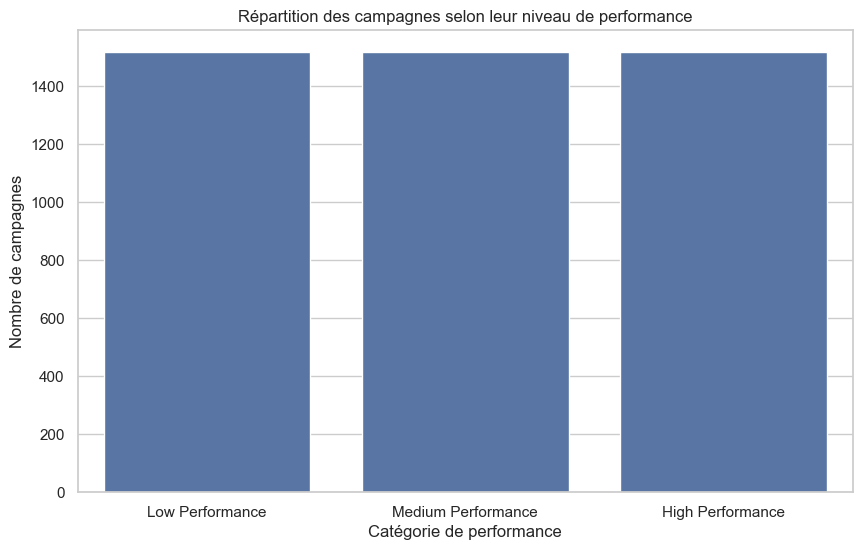

In [60]:
#ANALYSE DES CAMPAGNES FAIBLES / MOYENNES / FORTES

df["sales_category"] = pd.qcut(
    df["sales"],
    q=3,
    labels=["Low Performance", "Medium Performance", "High Performance"]
)

print(df["sales_category"].value_counts())

plt.figure()
sns.countplot(data=df, x="sales_category")
plt.title("Répartition des campagnes selon leur niveau de performance")
plt.xlabel("Catégorie de performance")
plt.ylabel("Nombre de campagnes")
plt.show()

### Interprétation — catégories de performance

Les campagnes sont réparties en trois groupes équilibrés : faible, moyenne et haute performance. Cette catégorisation est utile pour une analyse complémentaire ou pour transformer le problème en classification. Dans notre cas, elle permet surtout de comparer les niveaux de budget selon les performances commerciales.


In [61]:
# Budget moyen par catégorie de performance

performance_budget = df.groupby("sales_category")[budget_cols + ["total_budget", "roi"]].mean()

display(performance_budget)

,tv,radio,social_media,total_budget,roi
sales_category,,,,,
Low Performance,24.376649,8.718300,2.047225,35.142174,2.495230
Medium Performance,53.277228,17.647818,3.177568,74.102614,2.575981
High Performance,84.554455,28.112712,4.746468,117.413635,2.571275


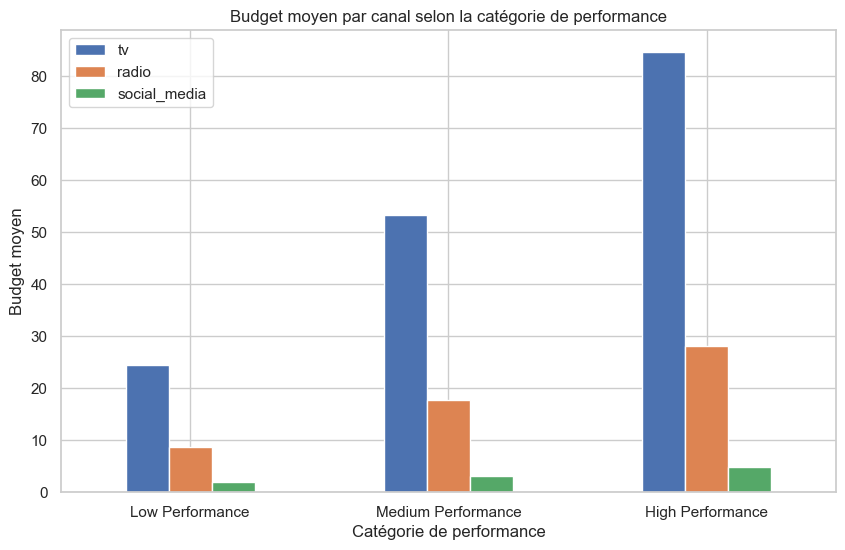

In [62]:
# Visualisation du budget moyen selon la performance

performance_budget[budget_cols].plot(kind="bar", figsize=(10, 6))
plt.title("Budget moyen par canal selon la catégorie de performance")
plt.xlabel("Catégorie de performance")
plt.ylabel("Budget moyen")
plt.xticks(rotation=0)
plt.show()

### Interprétation — budget moyen par niveau de performance

Le graphique montre clairement que les campagnes à haute performance ont des budgets moyens plus élevés, surtout en TV et en Radio. Les campagnes à faible performance ont des budgets plus faibles sur l’ensemble des canaux. Cela confirme que le niveau d’investissement joue un rôle important dans les ventes. En revanche, le ROI moyen reste assez proche entre les catégories, ce qui montre que plus de budget entraîne plus de ventes, mais pas forcément une rentabilité proportionnellement supérieure.


sales                 1.000000
tv                    0.999497
total_budget          0.986884
radio                 0.868638
social_media          0.527446
roi                   0.135389
tv_share              0.128300
radio_share          -0.000005
social_media_share   -0.298697
Name: sales, dtype: float64

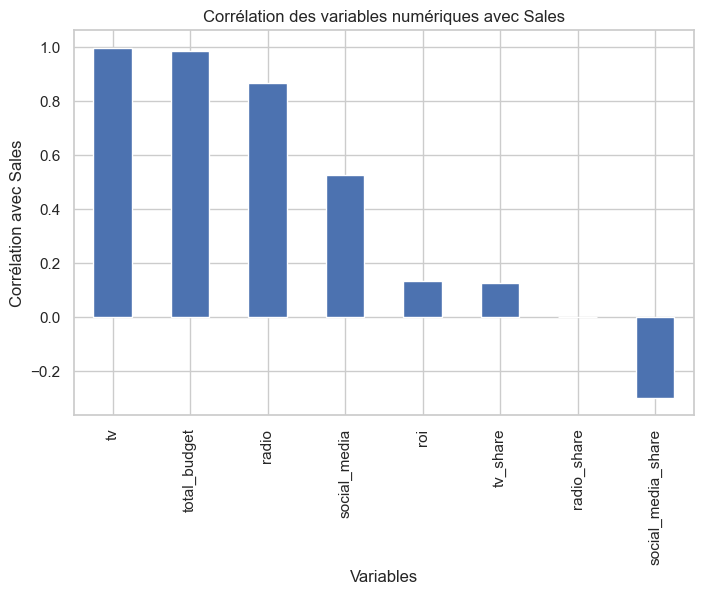

In [63]:
#SYNTHÈSE AUTOMATIQUE DES CORRÉLATIONS AVEC SALES

if "sales" in df.columns:
    sales_corr = df.corr(numeric_only=True)["sales"].sort_values(ascending=False)
    display(sales_corr)

    plt.figure(figsize=(8, 5))
    sales_corr.drop("sales").plot(kind="bar")
    plt.title("Corrélation des variables numériques avec Sales")
    plt.xlabel("Variables")
    plt.ylabel("Corrélation avec Sales")
    plt.show()

### Interprétation — corrélations avec Sales

La variable la plus corrélée avec `sales` est `tv`, avec une corrélation presque parfaite. `total_budget` est aussi très corrélé aux ventes, ce qui est logique puisqu’il inclut le budget TV. `radio` possède également une forte corrélation positive, tandis que `social_media` a une influence positive mais plus modérée. Le `roi` est faiblement corrélé à `sales`, ce qui confirme qu’il mesure une logique différente : la rentabilité plutôt que le volume de ventes.


In [67]:

OUTPUT_PATH = Path("../data/processed/marketing_and_sales_cleaned.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset nettoyé sauvegardé ici : {OUTPUT_PATH}")

Dataset nettoyé sauvegardé ici : ..\data\processed\marketing_and_sales_cleaned.csv


## Conclusion générale de l’EDA

Cette analyse exploratoire montre que le dataset est globalement propre : il contient très peu de valeurs manquantes, aucun doublon strict et des variables cohérentes avec le contexte marketing. Les quelques valeurs manquantes ont été supprimées car elles représentent une part très faible du dataset. Les outliers détectés, notamment sur `social_media` et `roi`, ne doivent pas être supprimés automatiquement, car ils peuvent correspondre à des campagnes marketing atypiques mais réalistes.

D’un point de vue métier, les ventes semblent principalement expliquées par le budget TV, puis par le budget Radio et le budget total. Le Social Media a aussi un effet positif, mais moins marqué. Le type d’influenceur est bien réparti dans les données, mais son impact direct sur les ventes et le ROI semble limité. Il pourra néanmoins être conservé dans la modélisation, car il peut interagir avec les budgets publicitaires.

Pour la suite du projet, la tâche la plus pertinente est donc une régression visant à prédire `sales` à partir de `tv`, `radio`, `social_media` et `influencer`. Le `roi` peut être conservé pour l’analyse métier et le dashboard, mais il ne doit pas être utilisé comme variable explicative pour prédire `sales`, car il est calculé à partir de la variable cible et créerait une fuite de données. La prochaine étape consiste à construire un pipeline de preprocessing, encoder la variable `influencer`, séparer les données en train/test, entraîner plusieurs modèles et comparer leurs performances.
